# AI기본법 QA 에이전트 성능 비교

V3 계획·재검색 에이전트와 V4 Grounding 에이전트의 정확도, 환각률, 근거 검색 성능, 응답 시간 및 API 호출 수를 비교한다.

> 현재 결과는 소규모 테스트셋을 이용한 평가 코드 검증용이며, 최종 발표에서는 30~35개 테스트셋의 결과로 갱신한다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


project_root = Path.cwd()

while (
    project_root != project_root.parent
    and not (
        project_root
        / "data"
        / "evaluation"
    ).exists()
):
    project_root = project_root.parent

summary_path = (
    project_root
    / "data"
    / "evaluation"
    / "results"
    / "agent_summary.csv"
)

summary_df = pd.read_csv(summary_path)

print("프로젝트 위치:", project_root)
print("평가 결과:", summary_path)

display(summary_df)

프로젝트 위치: C:\Users\p0526\OneDrive\바탕 화면\ai-act-agent
평가 결과: C:\Users\p0526\OneDrive\바탕 화면\ai-act-agent\data\evaluation\results\agent_summary.csv


,version,case_count,verdict_accuracy,answerability_precision,answerability_recall,answerability_f1,hallucination_rate,false_abstention_rate,mean_evidence_recall,average_latency_ms,median_latency_ms,average_api_calls
0,V3,2,1.0,1.0,1.0,1.0,0.0,0.0,1.0,11767.945,11767.945,3.0
1,V4,2,1.0,1.0,1.0,1.0,0.0,0.0,1.0,41342.265,41342.265,3.0


그래프 저장: C:\Users\p0526\OneDrive\바탕 화면\ai-act-agent\reports\figures\v3_v4_latency_comparison.png


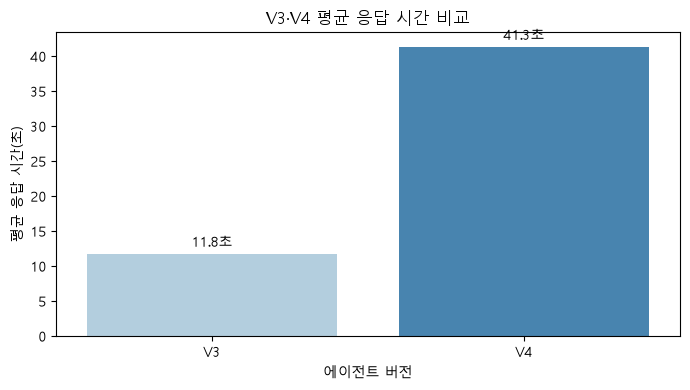

In [2]:
latency_df = summary_df.copy()

latency_df["average_latency_sec"] = (
    latency_df["average_latency_ms"]
    / 1000
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(
    figsize=(7, 4),
)

sns.barplot(
    data=latency_df,
    x="version",
    y="average_latency_sec",
    hue="version",
    palette="Blues",
    legend=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f초",
        padding=3,
    )

ax.set_title(
    "V3·V4 평균 응답 시간 비교"
)
ax.set_xlabel("에이전트 버전")
ax.set_ylabel("평균 응답 시간(초)")

plt.tight_layout()

figures_dir = (
    project_root
    / "reports"
    / "figures"
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

latency_figure_path = (
    figures_dir
    / "v3_v4_latency_comparison.png"
)

fig.savefig(
    latency_figure_path,
    dpi=200,
    bbox_inches="tight",
)

print(
    "그래프 저장:",
    latency_figure_path,
)

plt.show()

## 품질 지표 비교

- Verdict Accuracy: 기대한 `답변 확정` 또는 `판단 보류`를 올바르게 선택한 비율
- Answerability F1: 답변 가능한 질문과 판단을 보류해야 하는 질문을 구분한 성능
- Evidence Recall: 정답 근거 조문을 검색 결과에 포함한 비율
- Hallucination Rate: 근거가 없는 질문에 답변을 확정한 비율

현재 결과는 버전별 2개 질문만 사용한 임시 결과다.

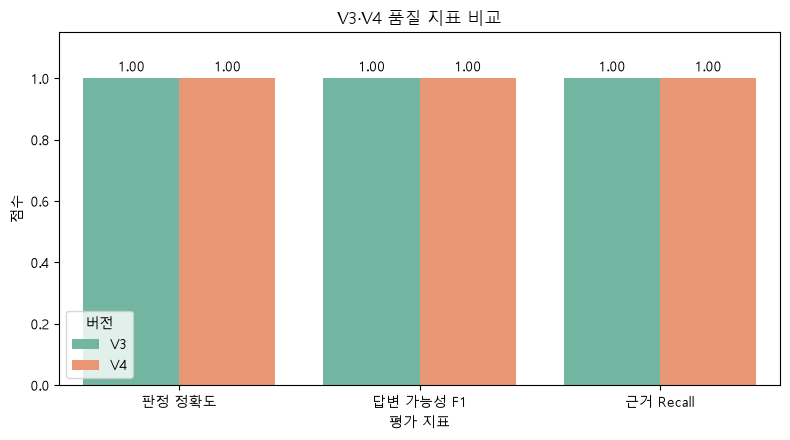

그래프 저장: C:\Users\p0526\OneDrive\바탕 화면\ai-act-agent\reports\figures\v3_v4_quality_comparison.png


In [3]:
quality_columns = {
    "verdict_accuracy": "판정 정확도",
    "answerability_f1": "답변 가능성 F1",
    "mean_evidence_recall": "근거 Recall",
}

quality_df = summary_df[
    [
        "version",
        *quality_columns.keys(),
    ]
].rename(
    columns=quality_columns
)

quality_long_df = quality_df.melt(
    id_vars="version",
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

sns.barplot(
    data=quality_long_df,
    x="metric",
    y="score",
    hue="version",
    palette="Set2",
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
    )

ax.set_title(
    "V3·V4 품질 지표 비교"
)
ax.set_xlabel("평가 지표")
ax.set_ylabel("점수")
ax.set_ylim(0, 1.15)
ax.legend(title="버전")

quality_figure_path = (
    figures_dir
    / "v3_v4_quality_comparison.png"
)

fig.savefig(
    quality_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()

print(
    "그래프 저장:",
    quality_figure_path,
)

## 현재 해석 및 다음 단계

- 현재 테스트에서는 V3와 V4 모두 판정 정확도, Answerability F1, 근거 Recall이 1.0이다.
- 현재 확인된 차이는 응답 시간이며, Grounding 검사를 수행하는 V4가 V3보다 느리다.
- 테스트 케이스가 버전별 2개뿐이므로 현재 결과로 최종 성능 우열을 판단할 수 없다.
- 최종 발표 전 정답이 검수된 30~35개 질문으로 다시 평가한다.
- 최종 평가에서는 질문 유형별 정확도, 환각률, 판단 보류 오류율과 중앙 응답 시간을 함께 비교한다.